<a href="https://colab.research.google.com/github/victoricoma/am-t4-s1a2026/blob/main/census0416_amt4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline | Carregamento e Detecção de Anomalias [Fase 1 - credit_data]

## Importar dados do Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [ ]:
!pip -q install plotly
!pip -q install yellowbrick

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Importar DataFrame [base_credit] - Descrição da Base

In [ ]:
base_census = pd.read_csv('/content/drive/MyDrive/am-t4/census.csv')

In [ ]:
base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
base_census.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Analise Exploratória de Anomalias [Alunos]

In [ ]:
base_census.isnull().sum()

,0
age,0
workclass,0
final-weight,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


# Pipeline | Visualização de Dados e Anomalias [Fase 2 base_credit]

In [10]:
np.unique(base_census['income'], return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

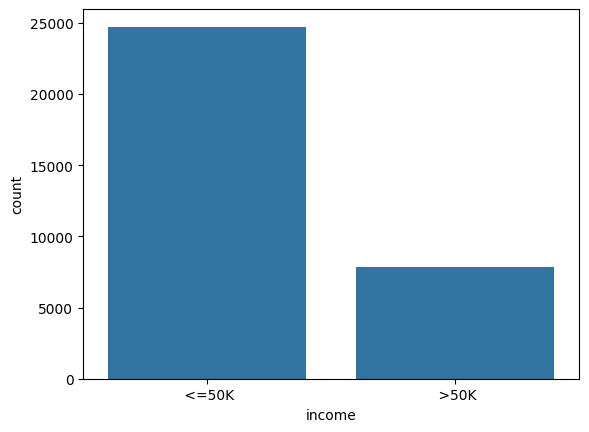

In [11]:
sns.countplot(x=base_census['income']);

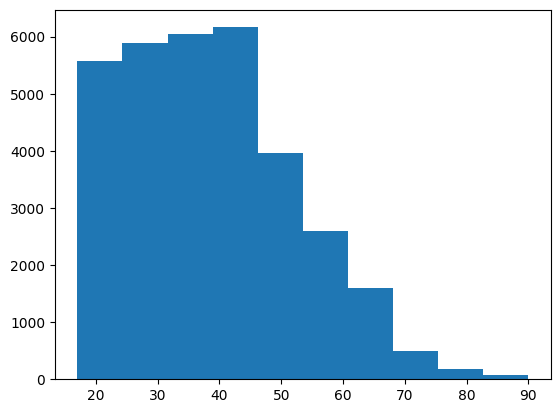

In [12]:
plt.hist(x = base_census['age']);

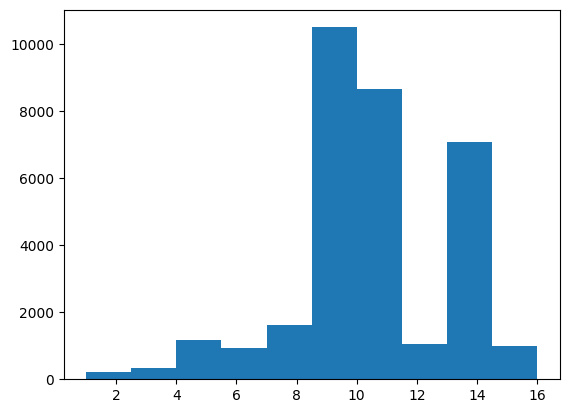

In [13]:
plt.hist(x = base_census['education-num'], bins=10);

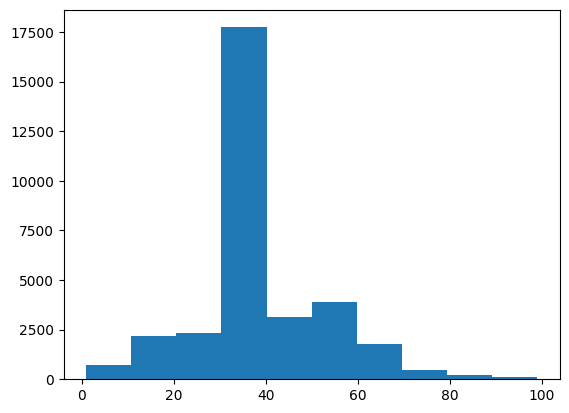

In [14]:
plt.hist(x = base_census['hour-per-week']);

In [15]:
grafico_grupos = px.treemap(base_census, path=['occupation','relationship','age'])
grafico_grupos.show()

## Eixo de Alvos de Aprendizagem

# Pipeline | Normalização de Dados  [Fase 3 - base_credit]

In [ ]:
base_credit.mean()

,0
clientid,1000.500000
income,45331.600018
age,40.807559
loan,4444.369695
default,0.141500


In [ ]:
base_credit['age'].mean()

np.float64(40.80755937840458)

In [ ]:
base_credit['age'][base_credit['age'] > 0].mean()

np.float64(40.92770044906149)

In [ ]:
base_credit.loc[base_credit['age'] < 0, 'age'] = base_credit['age'][base_credit['age']>0].mean()

In [ ]:
base_credit.loc[base_credit['age']<0]

,clientid,income,age,loan,default


In [ ]:
base_credit[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [ ]:
base_credit['age'].fillna(base_credit['age'].mean(), inplace=True)

/tmp/ipykernel_1186/1819494362.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
base_credit.loc[base_credit['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.9277,2082.625938,0
30,31,48528.852796,40.9277,6155.784670,0
31,32,23526.302555,40.9277,2862.010139,0


In [ ]:
type(base_credit)

pandas.core.frame.DataFrame

# Pipeline | Previsores e Classes Neurais [Fase 4 - base_credit]

## Vetores Neurais de Classes

In [ ]:
X_credit = base_credit.iloc[:, 1:4].values

In [ ]:
X_credit

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]])

In [ ]:
type(X_credit)

numpy.ndarray

In [ ]:
Y_credit = base_credit.iloc[:, 4].values

In [ ]:
Y_credit

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
type(Y_credit)

numpy.ndarray

## Organização de Escalas de Digestão

In [ ]:
X_credit[:, 0].min(), X_credit[:, 1].min(), X_credit[:, 2].min()

(np.float64(20014.4894700497),
 np.float64(18.055188510566897),
 np.float64(1.37762959325451))

In [ ]:
X_credit[:, 0].max(), X_credit[:, 1].max(), X_credit[:, 2].max()

(np.float64(69995.6855783239),
 np.float64(63.971795841120205),
 np.float64(13766.0512393337))

In [ ]:
(X_credit[:, 0].max() - X_credit[:, 0].min()), (X_credit[:, 1].max() - X_credit[:, 1].min()), (X_credit[:, 2].max() - X_credit[:, 2].min())


(np.float64(49981.196108274205),
 np.float64(45.916607330553305),
 np.float64(13764.673609740445))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()
X_credit = scaler_credit.fit_transform(X_credit)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_credit_treinamento, X_credit_teste, Y_credit_treinamento, Y_credit_teste = train_test_split(X_credit, Y_credit, test_size=0.15, random_state=0)

In [ ]:
import pickle

In [ ]:
with open('/content/drive/MyDrive/am-t4/credit.pkt', mode = 'wb') as f:
  pickle.dump([X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste], f)